# Unified Pu-Cl Cluster Analysis Notebook

This notebook provides a unified interface for Pu-Cl cluster analysis using three different graph-building methods:

1. **Voronoi OVITO**: Uses OVITO's `VoronoiAnalysisModifier`
2. **Voronoi freud**: Uses `freud` library for Voronoi tessellation
3. **Bond-based**: Uses OVITO's `CreateBondsModifier` with RDF-based cutoffs

All methods produce Pu-Cl graphs with both Pu and Cl nodes connected by Pu-Cl edges.
Cluster sizes count only Pu atoms (Pu-Cl-Pu connections count as one Pu oligomer).
Cluster IDs are assigned to both Pu and Cl atoms in the same component.


In [1]:
import sys
import os
from pathlib import Path
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

# Add paths
sys.path.append('/pscratch/sd/p/pvashi/irp/irp_mace_l_2/irp/density/cluster_analysis/utils')
sys.path.append('/pscratch/sd/p/pvashi/irp/irp_mace_l_2/irp/density/cluster_analysis/voronoi/ovito')
sys.path.append('/pscratch/sd/p/pvashi/irp/irp_mace_l_2/irp/density/cluster_analysis/voronoi/frued')
sys.path.append('/pscratch/sd/p/pvashi/irp/irp_mace_l_2/irp/density/cluster_analysis/bond_based')

# Import unified analysis functions
from pu_cl_analysis import (
    calculate_pu_cluster_sizes_from_graph,
    calculate_pu_cluster_ids_from_graph,
    analyze_pu_cluster_properties,
)

# Import graph building methods
# Method 1: Voronoi OVITO
try:
    from voronoi_ovito_utils import (
        build_mixed_voronoi_graph_from_pipeline,
        build_pu_cluster_graph_from_mixed,
    )
    from ovito.io import import_file as ovito_import_file
    OVITO_AVAILABLE = True
except ImportError:
    print("OVITO not available - Voronoi OVITO method disabled")
    OVITO_AVAILABLE = False

# Method 2: Voronoi freud
try:
    from voronoi_utils import build_pu_cl_graph
    from ase.io import read
    FREUD_AVAILABLE = True
except ImportError:
    print("freud/ASE not available - Voronoi freud method disabled")
    FREUD_AVAILABLE = False

# Method 3: Bond-based
try:
    from bondmodifier_utils import (
        canonical_cluster_workflow,
        build_shared_anion_graph,
    )
    BOND_AVAILABLE = True
except ImportError:
    print("Bond-based utilities not available")
    BOND_AVAILABLE = False

# Import plotting utilities
from plots import (
    std_plot_cluster_size_distribution,
    std_plot_graph_structure,
    std_plot_3d_graph_components_pu_only,
    setup_plot_style,
    extract_positions_from_data,
    extract_names_from_data,
)

# Set up plotting style
setup_plot_style()
print("Setup complete")

Setup complete


## Configuration

Configure your input file, frame selection, and method choice.

In [2]:
# Configuration
INPUT_PATH = '/pscratch/sd/p/pvashi/irp/irp_mace_l_2/irp/density/NaCl-PuCl3/x0.27/T900K/dump.lammpstrj'  # TODO: Update path
FRAME_INDEX = -1  # Use last frame, or specify index

# Method selection: 'ovito_voronoi', 'freud_voronoi', or 'bond_based'
METHOD = 'bond_based'  # Change this to switch methods

# Parameters
MIN_AREA = 0.2  # Minimum facet area for Voronoi methods
RDF_SAMPLES = 100  # For bond-based method

print(f"Method: {METHOD}")
print(f"Input: {INPUT_PATH}")

Method: bond_based
Input: /pscratch/sd/p/pvashi/irp/irp_mace_l_2/irp/density/NaCl-PuCl3/x0.27/T900K/dump.lammpstrj


## Data Loading

In [3]:
# Load data based on method
if METHOD == 'ovito_voronoi' and OVITO_AVAILABLE:
    pipeline = ovito_import_file(INPUT_PATH, multiple_frames=True)
    num_frames = pipeline.source.num_frames
    frame_idx = FRAME_INDEX if FRAME_INDEX >= 0 else num_frames - 1
    data = pipeline.compute(frame_idx)
    names = extract_names_from_data(data)
    positions = extract_positions_from_data(data)
    print(f"Loaded OVITO pipeline: {num_frames} frames")
    print(f"Using frame {frame_idx}")
    print(f"Atoms: {len(names)}")
    print(f"Species: {sorted(set(names))}")
elif METHOD == 'freud_voronoi' and FREUD_AVAILABLE:
    atoms_list = read(INPUT_PATH, index=FRAME_INDEX)
    if isinstance(atoms_list, list):
        atoms = atoms_list[0]
    else:
        atoms = atoms_list
    names = np.array(atoms.get_chemical_symbols())
    positions = atoms.get_positions()
    print(f"Loaded ASE atoms: {len(names)} atoms")
    print(f"Species: {sorted(set(names))}")
elif METHOD == 'bond_based' and BOND_AVAILABLE:
    pipeline = ovito_import_file(INPUT_PATH, multiple_frames=True)
    num_frames = pipeline.source.num_frames
    frame_idx = FRAME_INDEX if FRAME_INDEX >= 0 else num_frames - 1
    data = pipeline.compute(frame_idx)
    names = extract_names_from_data(data)
    positions = extract_positions_from_data(data)
    print(f"Loaded OVITO pipeline: {num_frames} frames")
    print(f"Using frame {frame_idx}")
    print(f"Atoms: {len(names)}")
    print(f"Species: {sorted(set(names))}")
else:
    raise ValueError(f"Method {METHOD} not available or not implemented")

Loaded OVITO pipeline: 13908 frames
Using frame 13907
Atoms: 3584
Species: [np.str_('Cl'), np.str_('Na'), np.str_('Pu')]


## Graph Building

Build Pu-Cl graph using selected method. All methods produce a graph with:
- Pu and Cl nodes
- Pu-Cl edges only (no Pu-Pu or Cl-Cl edges)

In [4]:
# Build graph based on method
if METHOD == 'ovito_voronoi':
    # Method 1: Voronoi OVITO
    mixed_graph = build_mixed_voronoi_graph_from_pipeline(
        pipeline, frame=frame_idx, min_area=MIN_AREA
    )
    G = build_pu_cluster_graph_from_mixed(mixed_graph, min_area=MIN_AREA)
    print(f"Built Pu-Cl graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
    
elif METHOD == 'freud_voronoi':
    # Method 2: Voronoi freud
    G = build_pu_cl_graph(atoms, min_area=MIN_AREA)
    print(f"Built Pu-Cl graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
    
elif METHOD == 'bond_based':
    # Method 3: Bond-based
    # First compute RDFs and cutoffs
    result = canonical_cluster_workflow(
        pipeline=pipeline,
        metals=['Pu'],
        anion='Cl',
        rdf_samples=RDF_SAMPLES,
    )
    print(result["graph"].number_of_nodes())
    # Build graph directly from data
    # sizes, cluster_ids, G = build_shared_anion_graph(
    #     data, names, anion='Cl', metals=['Pu']
    # )

    sizes, cluster_ids, G = result["sizes"], result["cluster_ids"], result["graph"]
    print(f"Built Pu-Cl graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
    print(f"Pairwise cutoffs: {result['pair_cutoffs']}")

# Verify graph structure
pu_nodes = [n for n in G.nodes() if G.nodes[n].get('species') == 'Pu']
cl_nodes = [n for n in G.nodes() if G.nodes[n].get('species') == 'Cl']
print(f"Pu nodes: {len(pu_nodes)}, Cl nodes: {len(cl_nodes)}")

2560
Built Pu-Cl graph: 2560 nodes, 2598 edges
Pairwise cutoffs: {('Pu', 'Cl'): 3.8967572603164884, ('Pu', 'Na'): 6.404925345463552, ('Pu', 'Pu'): 6.148827809160982, ('Cl', 'Pu'): 3.8967572603164884, ('Cl', 'Na'): 4.140601839284458, ('Cl', 'Cl'): 4.917143684879096, ('Na', 'Pu'): 6.404925345463552, ('Na', 'Cl'): 4.140601839284458, ('Na', 'Na'): 6.29678268195088}
Pu nodes: 384, Cl nodes: 2176


## Unified Analysis

All analysis functions work identically regardless of graph building method.

In [5]:
# Calculate cluster sizes (Pu atoms only)
cluster_sizes = calculate_pu_cluster_sizes_from_graph(G)
print(f"\nCluster Analysis:")
print(f"  Number of clusters: {len(cluster_sizes)}")
print(f"  Largest cluster size: {max(cluster_sizes) if cluster_sizes else 0} Pu atoms")
print(f"  Average cluster size: {np.mean(cluster_sizes) if cluster_sizes else 0:.2f} Pu atoms")

# Calculate cluster IDs (both Pu and Cl)
cluster_ids = calculate_pu_cluster_ids_from_graph(G, names)
print(f"\nCluster ID assignment:")
print(f"  Atoms with cluster IDs: {np.sum(cluster_ids >= 0)}")
print(f"  Unique clusters: {len(np.unique(cluster_ids[cluster_ids >= 0]))}")

# Graph properties
props = analyze_pu_cluster_properties(G)
print(f"\nGraph Properties:")
print(f"  Total nodes: {props['num_nodes']}")
print(f"  Pu nodes: {props['num_pu_nodes']}")
print(f"  Cl nodes: {props['num_cl_nodes']}")
print(f"  Total edges: {props['num_edges']}")
print(f"  Number of components: {props.get('num_components', 'N/A')}")


Cluster Analysis:
  Number of clusters: 38
  Largest cluster size: 304 Pu atoms
  Average cluster size: 10.11 Pu atoms

Cluster ID assignment:
  Atoms with cluster IDs: 2376
  Unique clusters: 38

Graph Properties:
  Total nodes: 2560
  Pu nodes: 384
  Cl nodes: 2176
  Total edges: 2598
  Number of components: 222


## Unified Plotting

Visualize clusters and graph structure.

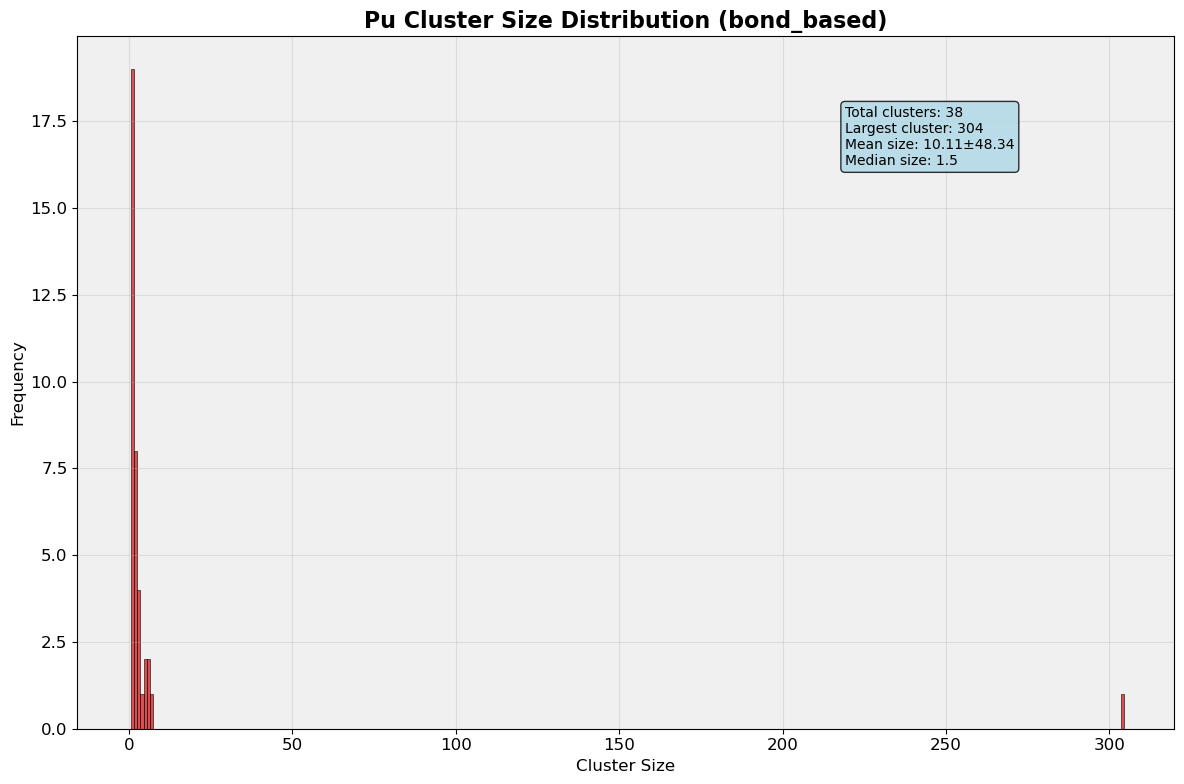

In [6]:
# Cluster size distribution
if cluster_sizes:
    std_plot_cluster_size_distribution(
        cluster_sizes,
        title=f"Pu Cluster Size Distribution ({METHOD})"
    )
else:
    print("No clusters found")

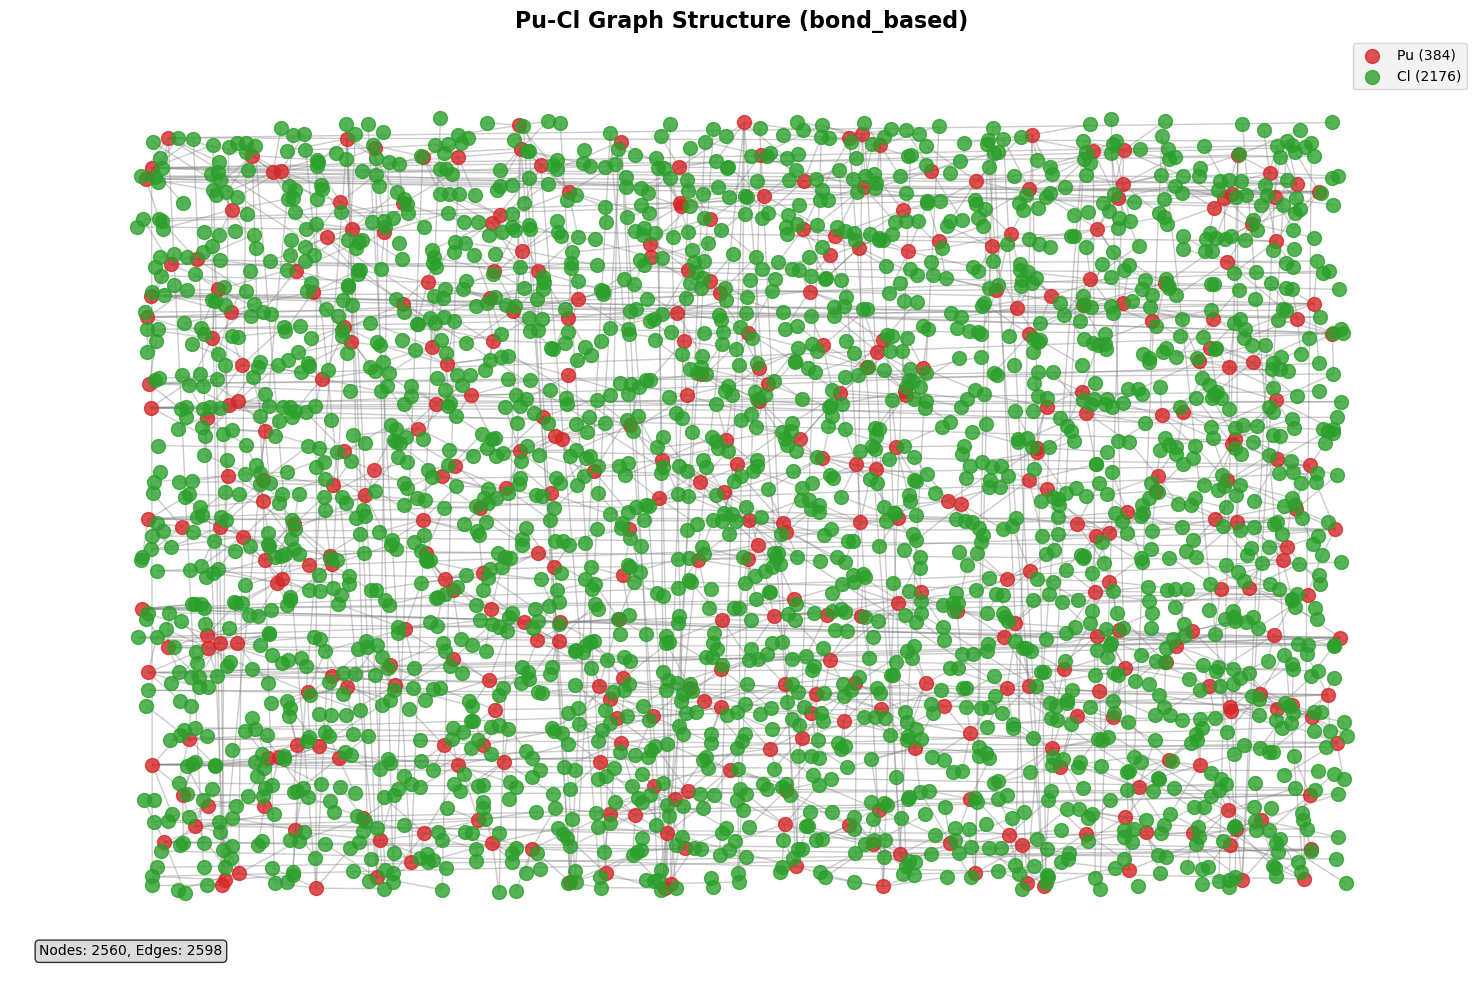

In [7]:
# Graph structure visualization
if G.number_of_nodes() > 0:
    std_plot_graph_structure(
        G,
        title=f"Pu-Cl Graph Structure ({METHOD})"
    )
else:
    print("Empty graph")

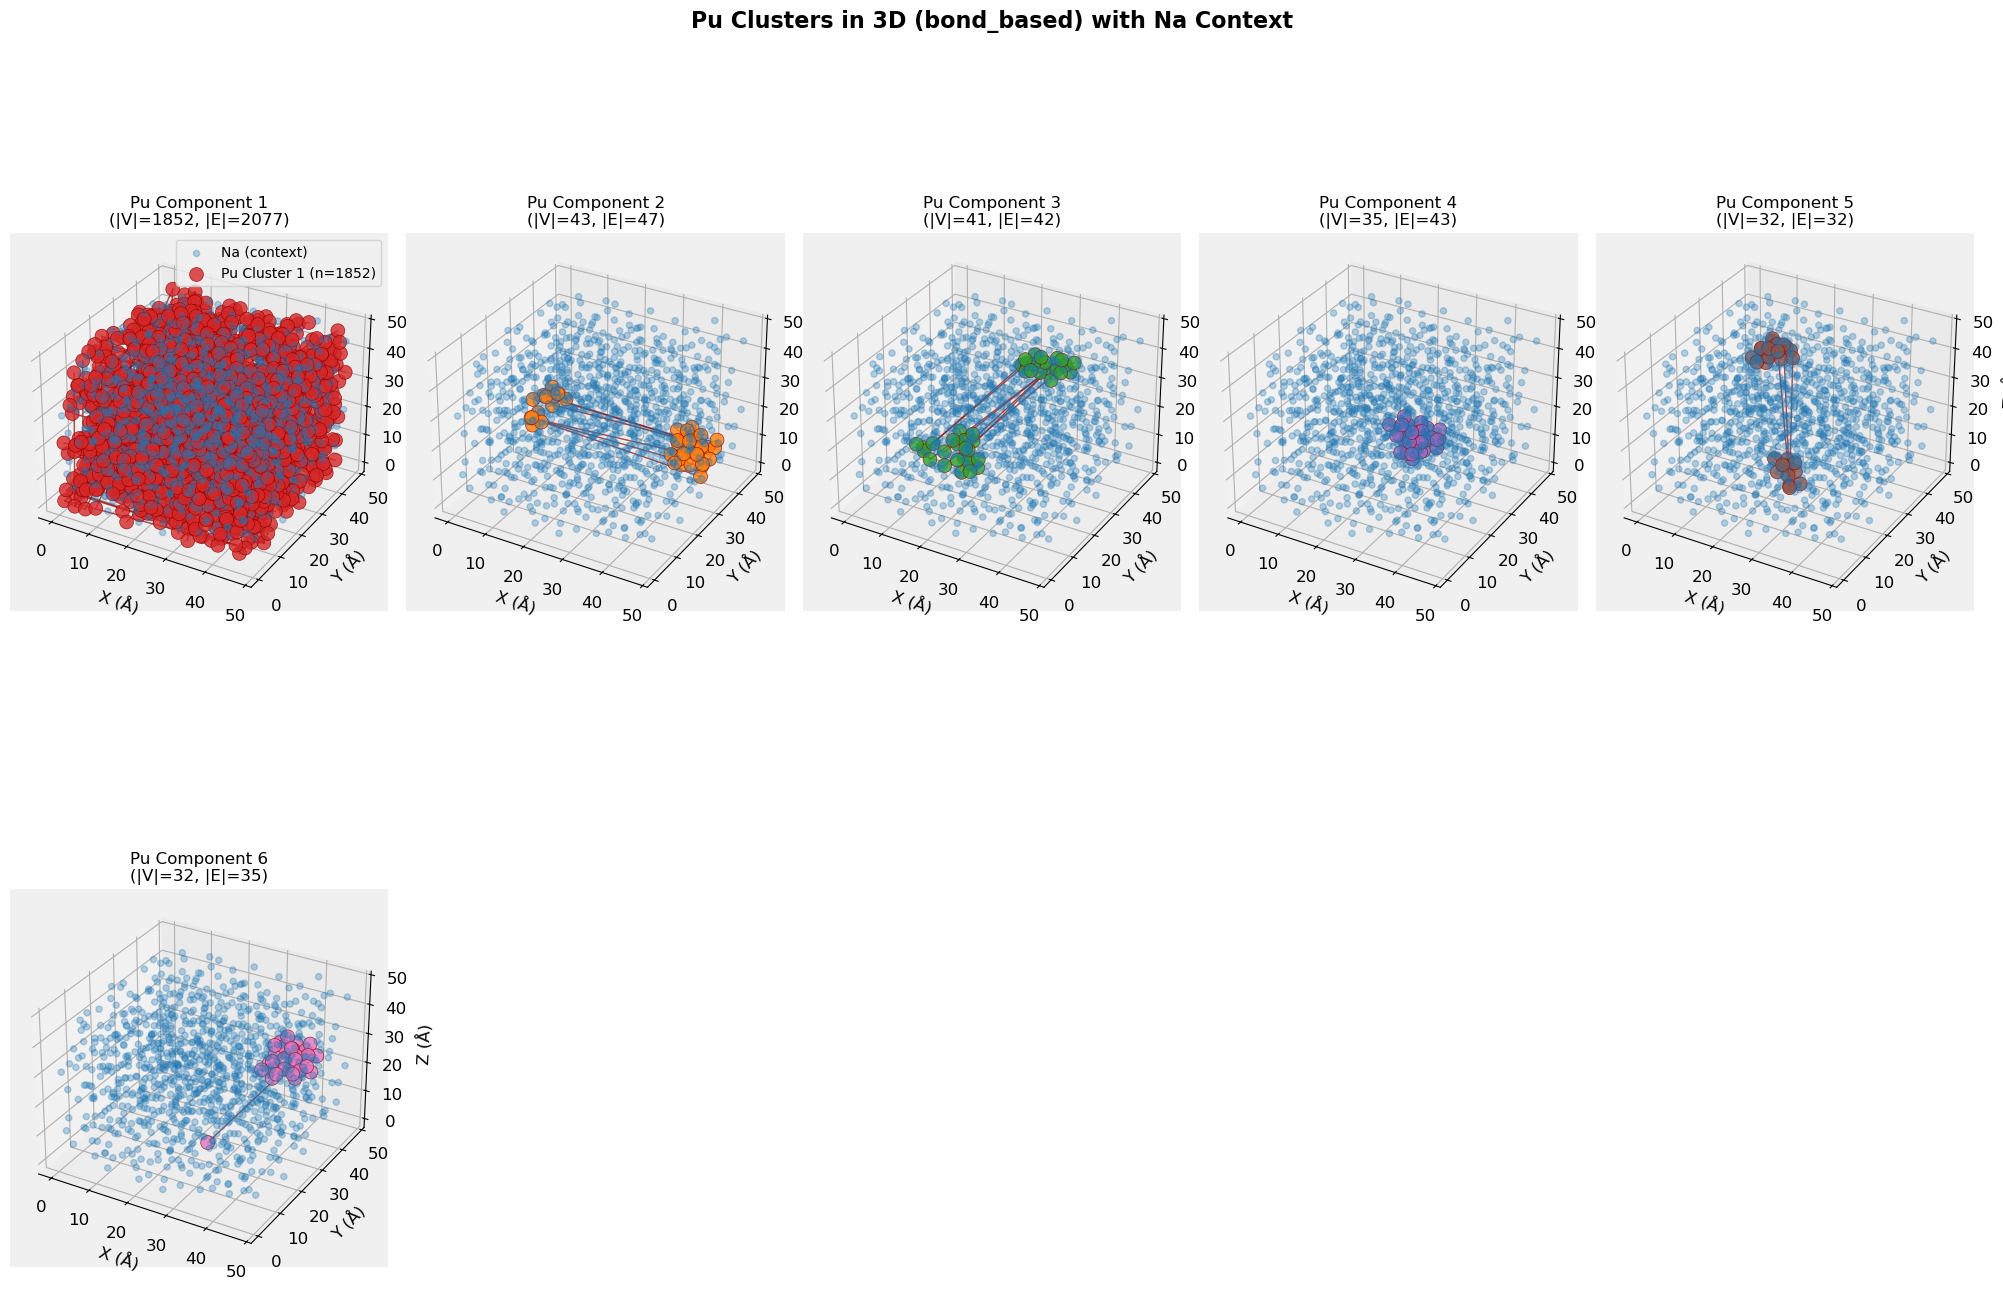

In [8]:
# 3D component visualization
if METHOD == 'ovito_voronoi' or METHOD == 'bond_based':
    # For OVITO-based methods
    std_plot_3d_graph_components_pu_only(
        G,
        data=data,
        names=names,
        max_components=6,
        title=f"Pu Clusters in 3D ({METHOD})"
    )
elif METHOD == 'freud_voronoi':
    # For ASE-based methods - need to create data-like object
    # This is a simplified version - you may need to adapt
    print("3D visualization for freud method requires data conversion")
    print("Consider using OVITO-based methods for full 3D visualization")

In [9]:
from plots import std_plot_3d_graph_components_pu_cl

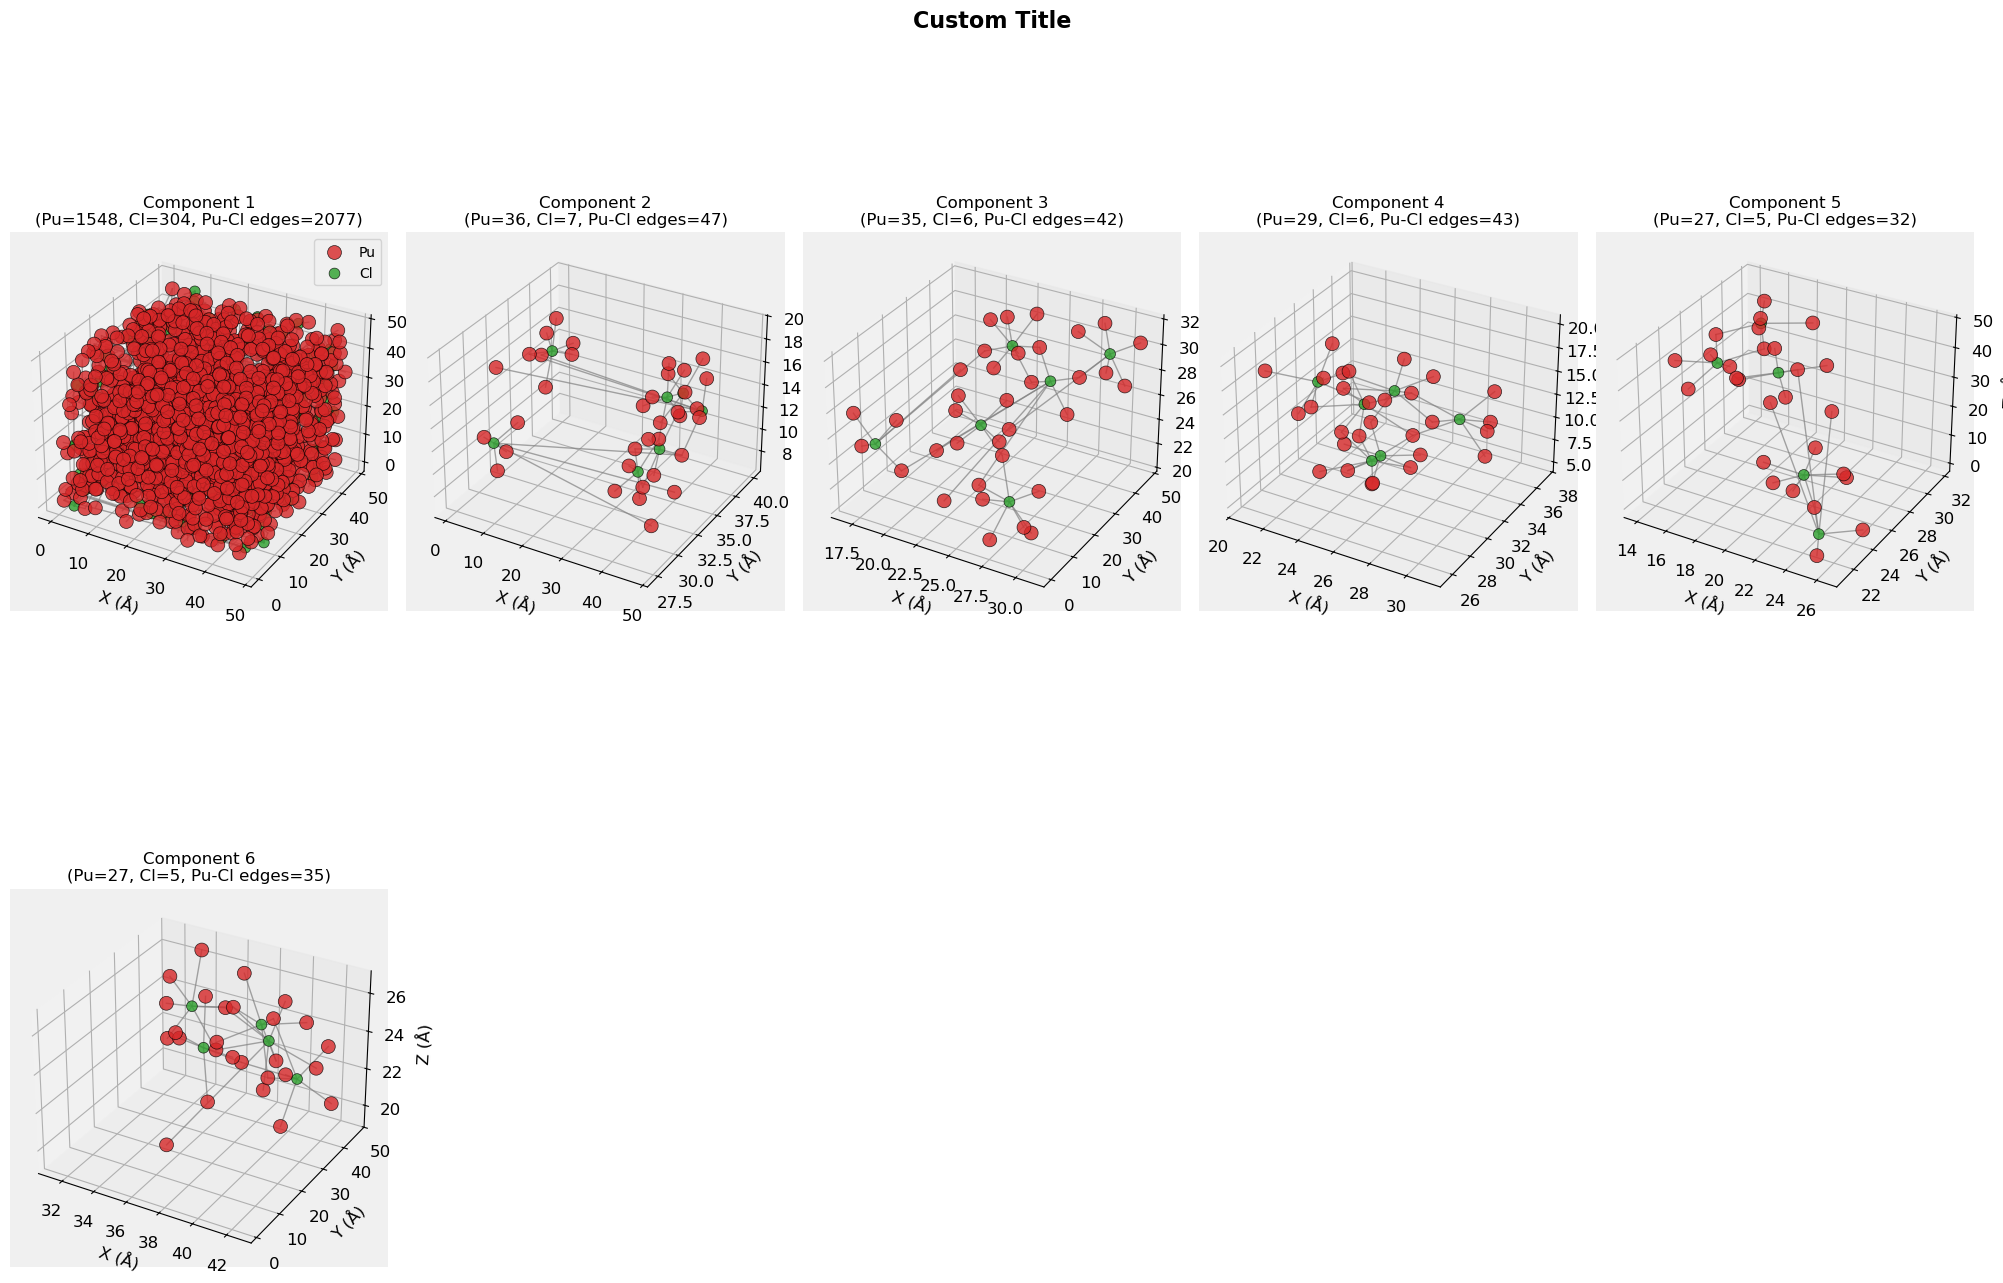

In [10]:
# 3D component visualization
if METHOD == 'ovito_voronoi' or METHOD == 'bond_based':
    # For OVITO-based methods
    std_plot_3d_graph_components_pu_cl(
        G,                          # Pu-Cl graph
        max_components=6,          # Number of components to plot
        show_na_context=False,      # Show Na atoms as background
        show_edges=True,           # Draw Pu-Cl edges
        data=data,                 # For Na context
        names=names,               # For Na context
        title="Custom Title"        # Optional custom title
    )
elif METHOD == 'freud_voronoi':
    # For ASE-based methods - need to create data-like object
    # This is a simplified version - you may need to adapt
    print("3D visualization for freud method requires data conversion")
    print("Consider using OVITO-based methods for full 3D visualization")

## Temporal Analysis (Optional)

Analyze cluster evolution over multiple frames.

  Frame 0/100...


  Frame 10/100...
  Frame 20/100...
  Frame 30/100...
  Frame 40/100...
  Frame 50/100...
  Frame 60/100...
  Frame 70/100...
  Frame 80/100...
  Frame 90/100...


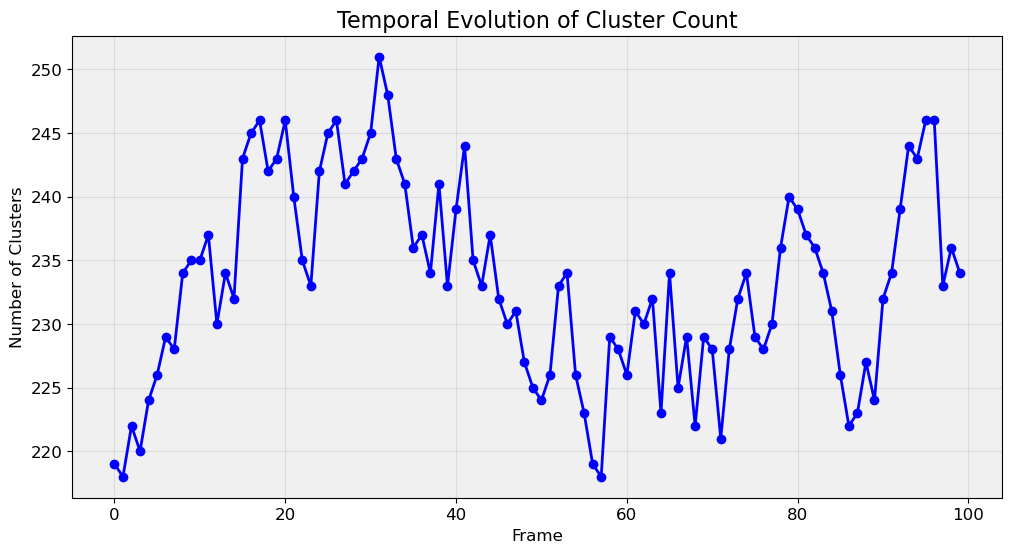

In [11]:
# Temporal analysis example
# Uncomment and modify as needed

temporal_cluster_sizes = []
temporal_num_clusters = []

frame_range = range(0, min(100, num_frames))  # Analyze first 100 frames
for frame in frame_range:
    if METHOD == 'ovito_voronoi':
        mixed_graph = build_mixed_voronoi_graph_from_pipeline(
            pipeline, frame=frame, min_area=MIN_AREA
        )
        G_frame = build_pu_cluster_graph_from_mixed(mixed_graph, min_area=MIN_AREA)
    elif METHOD == 'freud_voronoi':
        atoms_frame = atoms_list[frame]
        G_frame = build_pu_cl_graph(atoms_frame, min_area=MIN_AREA)
    elif METHOD == 'bond_based':
        data_frame = pipeline.compute(frame)
        names_frame = extract_names_from_data(data_frame)
        sizes_frame, _, G_frame = build_shared_anion_graph(
            data_frame, names_frame, anion='Cl', metals=['Pu']
        )
    
    sizes_frame = calculate_pu_cluster_sizes_from_graph(G_frame)
    temporal_cluster_sizes.append(sizes_frame)
    temporal_num_clusters.append(len(sizes_frame))
    
    if frame % 10 == 0:
        print(f"  Frame {frame}/{len(frame_range)}...")

# Plot temporal evolution
plt.figure(figsize=(12, 6))
plt.plot(range(len(frame_range)), temporal_num_clusters, 'b-o')
plt.xlabel('Frame')
plt.ylabel('Number of Clusters')
plt.title('Temporal Evolution of Cluster Count')
plt.grid(True, alpha=0.3)
plt.show()